In [2]:
import pandas as pd 
from sklearn.datasets import load_diabetes
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import  LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.model_selection import train_test_split 

In [3]:
du_lieu = load_diabetes()
df = pd.DataFrame(du_lieu.data , columns= du_lieu.feature_names)
print("Thông tin dữ liệu :")
print(df.info())
print("Kích thước dữ liệu: ", df.shape)
print("Thống kê mô tả dữ liệu: ")
print(df.describe())

Thông tin dữ liệu :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB
None
Kích thước dữ liệu:  (442, 10)
Thống kê mô tả dữ liệu: 
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072

In [4]:
# 4 : 
X = du_lieu.data
y = du_lieu.target
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size= 0.3)
print("Kích thước của dữ liệu x_train: ", x_train.shape)
print("Kích thước của dữ liệu x_test: ", x_test.shape)
print("Kích thước của dữ liệu y_train: ", y_train.shape)
print("Kích thước của dữ liệu Y_test: ", y_test.shape)

Kích thước của dữ liệu x_train:  (309, 10)
Kích thước của dữ liệu x_test:  (133, 10)
Kích thước của dữ liệu y_train:  (309,)
Kích thước của dữ liệu Y_test:  (133,)


In [5]:
# Huấn luyên mô hình 
chuan_hoa = StandardScaler()
x_train = chuan_hoa.fit_transform(x_train)
x_test = chuan_hoa.transform(x_test)
mo_hinh_lr = LinearRegression()
mo_hinh_lr.fit(x_train, y_train)
mo_hinh_gbr = GradientBoostingRegressor(n_estimators=50)
mo_hinh_gbr.fit(x_train, y_train)


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [6]:
# Dự đoán 
du_doan_lr = mo_hinh_lr.predict(x_test)
du_doan_gbr = mo_hinh_gbr.predict(x_test)

In [7]:
# Tính và hiển thị 
mese_gbr = mean_squared_error(y_test, du_doan_gbr)
r2_score_gbr = r2_score(y_test, du_doan_gbr)
mese_lr = mean_squared_error(y_test, du_doan_lr)
r2_score_lr = r2_score(y_test, du_doan_lr)
print("Gradient Boosting Regressor")
print("MSE:", mese_gbr)
print("R2:", r2_score_gbr)
print("Linear Regression")
print("MSE:", mese_lr)
print("R2:", r2_score_lr)

Gradient Boosting Regressor
MSE: 2958.821384286527
R2: 0.45189835133578005
Linear Regression
MSE: 2821.750981001311
R2: 0.4772897164322617


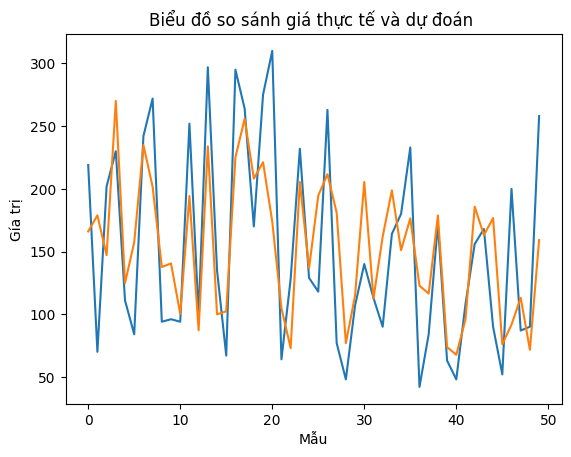

In [10]:
import matplotlib.pyplot as plt 
plt.plot(y_test[: 50], label = 'Gía trị thực tế ')
plt.plot(du_doan_gbr[:50], label = "Gía trị dự đoán ")
plt.xlabel("Mẫu")
plt.ylabel("Gía trị")
plt.title("Biểu đồ so sánh giá thực tế và dự đoán ")
plt.show()